In [1]:
import pandas as pd
import numpy as np

1. Load and inspect data — Display basic information (shape, data types, first few rows), check for missing
values and duplicates

In [3]:
data_path = "/content/fake_and_real_news(1).csv"
df = pd.read_csv(data_path)

In [4]:
print(f"Shape: {df.shape}")

Shape: (9900, 2)


In [5]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [6]:
df.dtypes

,0
Text,object
label,object


In [7]:
df.describe()

,Text,label
count,9900,9900
unique,9865,2
top,Highlights: The Trump presidency on April 13 a...,Fake
freq,8,5000


In [8]:
print(df.duplicated().sum())

35


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.duplicated().sum())

0


2. Label distribution — Count and visualize how many Fake vs Real articles are in the dataset. Is it
balanced?

In [11]:
df['label'].value_counts()

,count
label,
Fake,5000
Real,4865


Text length analysis — Plot the distribution of article lengths for Fake vs Real separately. Do fake
articles tend to be longer or shorter?

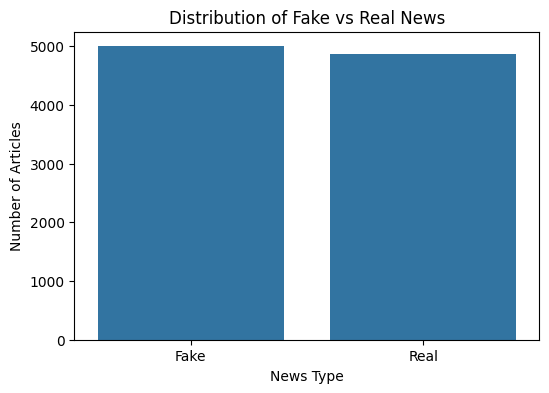

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)

plt.title("Distribution of Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

In [21]:
import pandas as pd
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords


# Define stopwords
stop_words = set(stopwords.words('english'))

# Function using your logic
def remove_stopwords(text):

    tokens = text.split()   # convert sentence to tokens

    filtered = [word for word in tokens if word.lower() not in stop_words]

    return " ".join(filtered)   # convert list back to sentence


# Apply to dataset
df["clean_text"] = df["Text"].apply(remove_stopwords)

# Show result
print(df[["Text","clean_text"]].head())

                                                Text  \
0   Top Trump Surrogate BRUTALLY Stabs Him In The...   
1  U.S. conservative leader optimistic of common ...   
2  Trump proposes U.S. tax overhaul, stirs concer...   
3   Court Forces Ohio To Allow Millions Of Illega...   
4  Democrats say Trump agrees to work on immigrat...   

                                          clean_text  
0  Top Trump Surrogate BRUTALLY Stabs Back: ‘He’s...  
1  U.S. conservative leader optimistic common gro...  
2  Trump proposes U.S. tax overhaul, stirs concer...  
3  Court Forces Ohio Allow Millions Illegally Pur...  
4  Democrats say Trump agrees work immigration bi...  
